# Extreme Streamflow Prediction Using Temporal Features

# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np

from google.colab import files
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# 2. Load Dataset

In [ ]:
#Load as a CSV file
uploaded = files.upload()


file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

df.head()

Saving ML_streamflow_meteorological_data.csv to ML_streamflow_meteorological_data.csv


,Date,Streamflow,Precipitation,Temperature
0,1962-01-01,8.74,0.0,10.1
1,1962-01-02,6.35,0.0,10.2
2,1962-01-03,5.45,0.0,13.5
3,1962-01-04,5.09,0.0,10.2
4,1962-01-05,4.73,1.0,6.9


#3. Methodology

## 3.1. Data Preprocessing

In [ ]:
df.describe()

,Streamflow,Precipitation,Temperature
count,18536.000000,18403.000000,18388.000000
mean,8.863350,1.625420,16.474260
std,21.353546,5.434524,7.712399
min,0.000000,0.000000,-6.000000
25%,0.168000,0.000000,10.300000
50%,1.600000,0.000000,16.100000
75%,7.500000,0.000000,23.300000
max,614.000000,78.100000,34.600000


In [ ]:
# Data Preprocessing

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18536 entries, 0 to 18535
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           18536 non-null  datetime64[ns]
 1   Streamflow     18536 non-null  float64       
 2   Precipitation  18403 non-null  float64       
 3   Temperature    18388 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 579.4 KB


### 3.2. Target Definition

In [ ]:
# Target Definition

threshold = df["Streamflow"].quantile(0.90)

df["target"] = (df["Streamflow"] > threshold).astype(int)

print("Threshold:", threshold)

df["target"].value_counts()

Threshold: 23.5


,count
target,
0,16687
1,1849


<Axes: xlabel='target'>

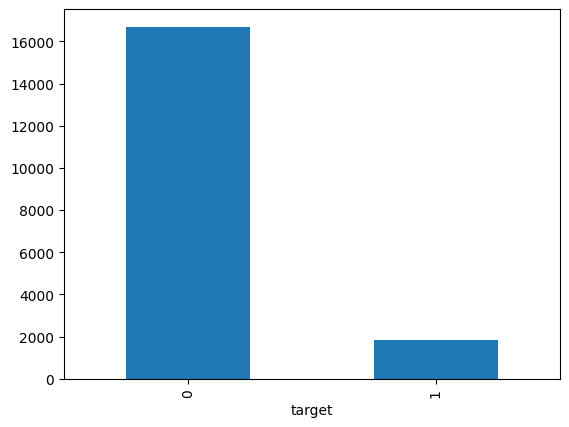

In [ ]:
#Distribution

df["target"].value_counts(normalize=True)
df["target"].value_counts().plot(kind="bar")

## 3.3 Feature Engineering

In [ ]:
# Feature Engineering

lag_windows = [1, 2, 3, 5, 7, 10, 14, 20, 30]

for lag in lag_windows:

    df[f"flow_lag_{lag}"] = df["Streamflow"].shift(lag)

    df[f"precip_lag_{lag}"] = df["Precipitation"].shift(lag)

    df[f"temp_lag_{lag}"] = df["Temperature"].shift(lag)

In [ ]:
# Aggregated Precipitation Features

rolling_windows = [3, 5, 7, 10, 14, 20, 30]

for window in rolling_windows:

    df[f"precip_sum_{window}"] = (
        df["Precipitation"].rolling(window).sum()
    )

In [ ]:
#Drop NAN values

df = df.dropna()

df.head()

,Date,Streamflow,Precipitation,Temperature,target,flow_lag_1,precip_lag_1,temp_lag_1,flow_lag_2,precip_lag_2,...,flow_lag_30,precip_lag_30,temp_lag_30,precip_sum_3,precip_sum_5,precip_sum_7,precip_sum_10,precip_sum_14,precip_sum_20,precip_sum_30
30,1962-01-31,123.0,57.7,12.0,1,18.2,13.2,10.1,3.95,5.3,...,8.74,0.0,10.1,76.2,97.2,97.2,97.2,97.2,97.2,98.4
31,1962-02-01,168.0,15.4,10.6,1,123.0,57.7,12.0,18.20,13.2,...,6.35,0.0,10.2,86.3,112.6,112.6,112.6,112.6,112.6,113.8
32,1962-02-02,124.0,6.8,9.8,1,168.0,15.4,10.6,123.00,57.7,...,5.45,0.0,13.5,79.9,98.4,119.4,119.4,119.4,119.4,120.6
33,1962-02-03,110.0,10.8,9.9,1,124.0,6.8,9.8,168.00,15.4,...,5.09,0.0,10.2,33.0,103.9,130.2,130.2,130.2,130.2,131.4
34,1962-02-04,93.8,10.1,8.3,1,110.0,10.8,9.9,124.00,6.8,...,4.73,1.0,6.9,27.7,100.8,119.3,140.3,140.3,140.3,140.5


## 3.4. Train-Test Split

In [ ]:
# Train-Test Split

train_size = int(len(df) * 0.7)

train = df.iloc[:train_size]

test = df.iloc[train_size:]

In [ ]:
#Feature List

features = [col for col in df.columns if "lag" in col or "sum" in col]

print(features)

['flow_lag_1', 'precip_lag_1', 'temp_lag_1', 'flow_lag_2', 'precip_lag_2', 'temp_lag_2', 'flow_lag_3', 'precip_lag_3', 'temp_lag_3', 'flow_lag_5', 'precip_lag_5', 'temp_lag_5', 'flow_lag_7', 'precip_lag_7', 'temp_lag_7', 'flow_lag_10', 'precip_lag_10', 'temp_lag_10', 'flow_lag_14', 'precip_lag_14', 'temp_lag_14', 'flow_lag_20', 'precip_lag_20', 'temp_lag_20', 'flow_lag_30', 'precip_lag_30', 'temp_lag_30', 'precip_sum_3', 'precip_sum_5', 'precip_sum_7', 'precip_sum_10', 'precip_sum_14', 'precip_sum_20', 'precip_sum_30']


In [ ]:
#X and y

X_train = train[features]
y_train = train["target"]

X_test = test[features]
y_test = test["target"]

# 4. Baseline Model

## 4.1. Baseline Model: Logistic Regression

### 4.1.1. Implemention of Logistic Regression

In [ ]:
# Logistic Regression

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

In [ ]:
lr_preds = lr_model.predict(X_test)

### 4.1.2. Model Evaluation of Logistic Regression




In [ ]:
# Model Evaluation of Logistic Regression

# Train Performance

lr_train_preds = lr_model.predict(X_train)

print(classification_report(y_train, lr_train_preds))
print("Recall:", recall_score(y_train, lr_train_preds))
print("F1 Score:", f1_score(y_train, lr_train_preds))


              precision    recall  f1-score   support

           0       1.00      0.97      0.98     11164
           1       0.82      0.98      0.89      1551

    accuracy                           0.97     12715
   macro avg       0.91      0.97      0.94     12715
weighted avg       0.97      0.97      0.97     12715

Recall: 0.9774339136041263
F1 Score: 0.8888888888888888


In [ ]:
# Test Performance

print(classification_report(y_test, lr_preds))
print("Recall:", recall_score(y_test,lr_preds))
print("F1 Score:", f1_score(y_test, lr_preds))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99      5152
           1       0.68      0.97      0.80       298

    accuracy                           0.97      5450
   macro avg       0.84      0.97      0.89      5450
weighted avg       0.98      0.97      0.98      5450

Recall: 0.9697986577181208
F1 Score: 0.7994467496542186


## 4.2. Baseline Model: Random Forest

### 4.2.1. Implemention of Random Forest

In [ ]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
rf_preds = rf_model.predict(X_test)

### 4.2.2. Model Evaluation of Random Forest

In [ ]:
# Model Evaluation of Random Forest

# Train Performance

rf_train_preds = rf_model.predict(X_train)

print(classification_report(y_train, rf_train_preds))
print("Recall:", recall_score(y_train, rf_train_preds))
print("F1 Score:", f1_score(y_train, rf_train_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11164
           1       1.00      1.00      1.00      1551

    accuracy                           1.00     12715
   macro avg       1.00      1.00      1.00     12715
weighted avg       1.00      1.00      1.00     12715

Recall: 1.0
F1 Score: 1.0


In [ ]:
# Test Performance

print(classification_report(y_test, rf_preds))
print("Recall:", recall_score(y_test, rf_preds))
print("F1 Score:", f1_score(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5152
           1       0.87      0.79      0.83       298

    accuracy                           0.98      5450
   macro avg       0.93      0.89      0.91      5450
weighted avg       0.98      0.98      0.98      5450

Recall: 0.7885906040268457
F1 Score: 0.8260105448154658


In [ ]:
# Random Forest Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_rf = confusion_matrix(y_test, rf_preds)

tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print(cm_rf)

[[5116   36]
 [  63  235]]


## 4.3. Baseline Model: XGBoost

In [ ]:
!pip install xgboost

### 4.3.1. Implemention of XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

###4.3.2. Model Evaluation of XGBoost

In [ ]:
# Model Evaluation of XGBoost

# Train Performance

xgb_train_preds = xgb_model.predict(X_train)

print(classification_report(y_train, xgb_train_preds))
print("Recall:", recall_score(y_train, xgb_train_preds))
print("F1 Score:", f1_score(y_train, xgb_train_preds))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     11164
           1       0.98      0.95      0.96      1551

    accuracy                           0.99     12715
   macro avg       0.99      0.97      0.98     12715
weighted avg       0.99      0.99      0.99     12715

Recall: 0.9497098646034816
F1 Score: 0.9646365422396856


In [ ]:
# Test Performance

print(classification_report(y_test, xgb_preds))
print("Recall:", recall_score(y_test, xgb_preds))
print("F1 Score:", f1_score(y_test, xgb_preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5152
           1       0.88      0.85      0.87       298

    accuracy                           0.99      5450
   macro avg       0.94      0.92      0.93      5450
weighted avg       0.99      0.99      0.99      5450

Recall: 0.8523489932885906
F1 Score: 0.8654173764906303


## 4.4. Baseline Model: LightGBM

In [ ]:
!pip install lightgbm

### 4.4.1. Implemention of LightGBM

In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

lgbm_preds = lgbm_model.predict(X_test)

[LightGBM] [Info] Number of positive: 1551, number of negative: 11164
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007904 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8670
[LightGBM] [Info] Number of data points in the train set: 12715, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.121982 -> initscore=-1.973794
[LightGBM] [Info] Start training from score -1.973794
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [ ]:
lgbm_train_preds = lgbm_model.predict(X_train)

print(classification_report(y_train, lgbm_train_preds))
print("Recall:", recall_score(y_train, lgbm_train_preds))
print("F1 Score:", f1_score(y_train, lgbm_train_preds))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     11164
           1       0.98      0.95      0.97      1551

    accuracy                           0.99     12715
   macro avg       0.99      0.97      0.98     12715
weighted avg       0.99      0.99      0.99     12715

Recall: 0.9522888459058672
F1 Score: 0.9650441032342372


In [ ]:
print(classification_report(y_test, lgbm_preds))
print("Recall:", recall_score(y_test, lgbm_preds))
print("F1 Score:", f1_score(y_test, lgbm_preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5152
           1       0.86      0.86      0.86       298

    accuracy                           0.98      5450
   macro avg       0.93      0.93      0.93      5450
weighted avg       0.98      0.98      0.98      5450

Recall: 0.8590604026845637
F1 Score: 0.8619528619528619


#5. Feature Importance

In [ ]:
# Feature Importance - XGBoost

xgb_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance.head(10)

,Feature,Importance
0,flow_lag_1,0.503893
27,precip_sum_3,0.055863
33,precip_sum_30,0.050355
12,flow_lag_7,0.032377
4,precip_lag_2,0.032073
3,flow_lag_2,0.023585
28,precip_sum_5,0.022668
18,flow_lag_14,0.020529
6,flow_lag_3,0.019793
17,temp_lag_10,0.018927


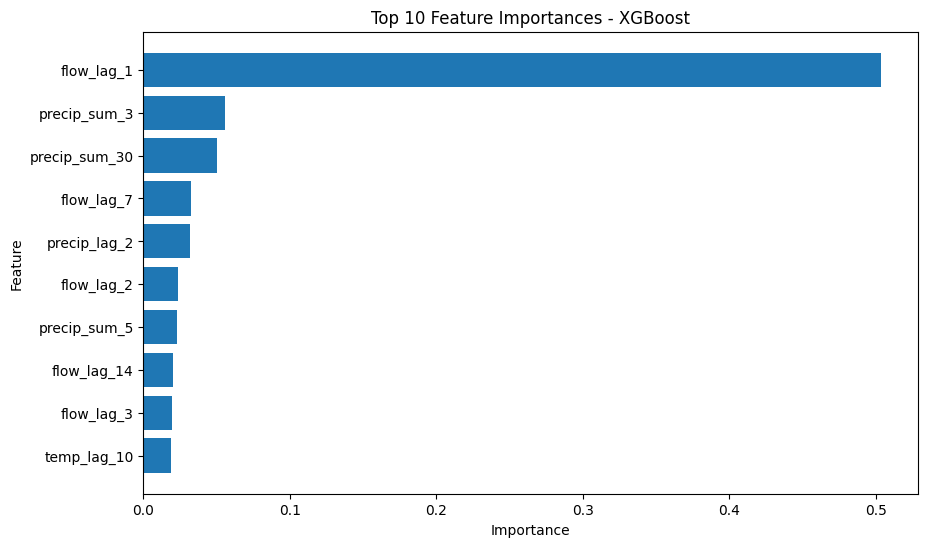

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    xgb_importance["Feature"].head(10),
    xgb_importance["Importance"].head(10)
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - XGBoost")
plt.show()

In [ ]:
# Feature Importance - LightGBM

lgbm_importance = pd.DataFrame({
    "Feature": features,
    "Importance": lgbm_model.feature_importances_
})

lgbm_importance = lgbm_importance.sort_values(
    by="Importance",
    ascending=False
)

lgbm_importance.head(10)


,Feature,Importance
0,flow_lag_1,155
27,precip_sum_3,80
4,precip_lag_2,35
21,flow_lag_20,34
2,temp_lag_1,29
28,precip_sum_5,28
6,flow_lag_3,27
18,flow_lag_14,25
23,temp_lag_20,25
12,flow_lag_7,22


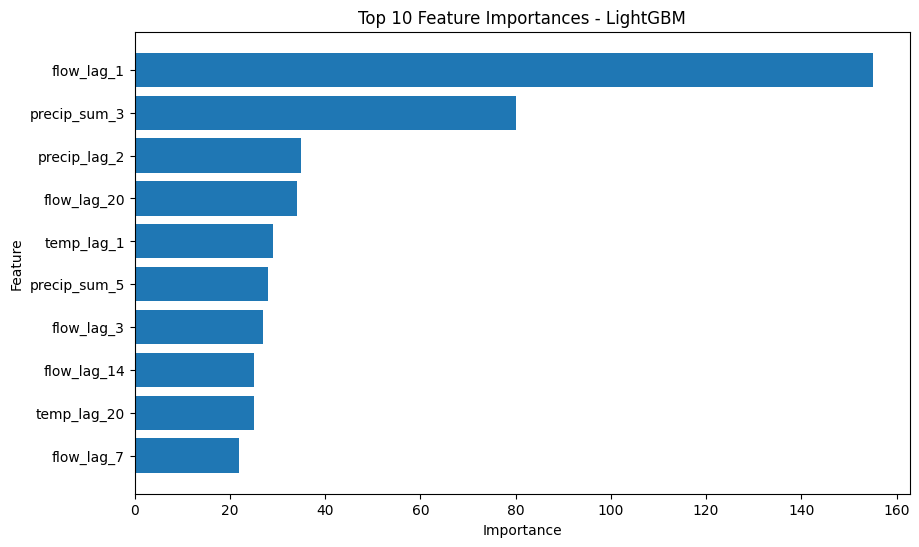

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    lgbm_importance["Feature"].head(10),
    lgbm_importance["Importance"].head(10)
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - LightGBM")
plt.show()


#6. Lag Ablation Study and Temporal Window Comparison


##6.1 Lookback Window Ablation

In [ ]:
# Extended Lag Ablation Study

lookback_results = []

windows = [1, 3, 5, 7, 10, 14, 20, 30]

for w in windows:

    feature_set = []

    for lag in lag_windows:

        if lag <= w:

            feature_set.append(f"flow_lag_{lag}")
            feature_set.append(f"precip_lag_{lag}")
            feature_set.append(f"temp_lag_{lag}")

    for rolling in rolling_windows:

        if rolling <= w:
            feature_set.append(f"precip_sum_{rolling}")

    X_train_w = train[feature_set]
    X_test_w = test[feature_set]

    # XGBoost

    xgb_model_w = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    )

    xgb_model_w.fit(X_train_w, y_train)

    xgb_preds_w = xgb_model_w.predict(X_test_w)

    xgb_recall = recall_score(y_test, xgb_preds_w)
    xgb_f1 = f1_score(y_test, xgb_preds_w)

    cm_xgb = confusion_matrix(y_test, xgb_preds_w)

    tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()

    # LightGBM

    lgbm_model_w = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    lgbm_model_w.fit(X_train_w, y_train)

    lgbm_preds_w = lgbm_model_w.predict(X_test_w)

    lgbm_recall = recall_score(y_test, lgbm_preds_w)
    lgbm_f1 = f1_score(y_test, lgbm_preds_w)

    cm_lgbm = confusion_matrix(y_test, lgbm_preds_w)

    tn_lgbm, fp_lgbm, fn_lgbm, tp_lgbm = cm_lgbm.ravel()

    lookback_results.append({

    "Window": w,

    "XGB TP": tp_xgb,
    "XGB TN": tn_xgb,
    "XGB FP": fp_xgb,
    "XGB FN": fn_xgb,

    "XGB Recall": xgb_recall,
    "XGB F1": xgb_f1,

    "LGBM TP": tp_lgbm,
    "LGBM TN": tn_lgbm,
    "LGBM FP": fp_lgbm,
    "LGBM FN": fn_lgbm,

    "LGBM Recall": lgbm_recall,
    "LGBM F1": lgbm_f1
    })

lookback_results_df = pd.DataFrame(lookback_results)

lookback_results_df

[LightGBM] [Info] Number of positive: 1551, number of negative: 11164
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000887 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 12715, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.121982 -> initscore=-1.973794
[LightGBM] [Info] Start training from score -1.973794
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,Window,XGB TP,XGB TN,XGB FP,XGB FN,XGB Recall,XGB F1,LGBM TP,LGBM TN,LGBM FP,LGBM FN,LGBM Recall,LGBM F1
0,1,231,5107,45,67,0.775168,0.804878,232,5111,41,66,0.778523,0.812609
1,3,260,5117,35,38,0.872483,0.876897,254,5116,36,44,0.852349,0.863946
2,5,250,5115,37,48,0.838926,0.854701,248,5118,34,50,0.832215,0.855172
3,7,254,5122,30,44,0.852349,0.872852,251,5117,35,47,0.842282,0.859589
4,10,252,5124,28,46,0.845638,0.871972,255,5121,31,43,0.855705,0.873288
5,14,253,5117,35,45,0.848993,0.863481,253,5117,35,45,0.848993,0.863481
6,20,254,5115,37,44,0.852349,0.862479,255,5111,41,43,0.855705,0.858586
7,30,254,5117,35,44,0.852349,0.865417,256,5112,40,42,0.859060,0.861953


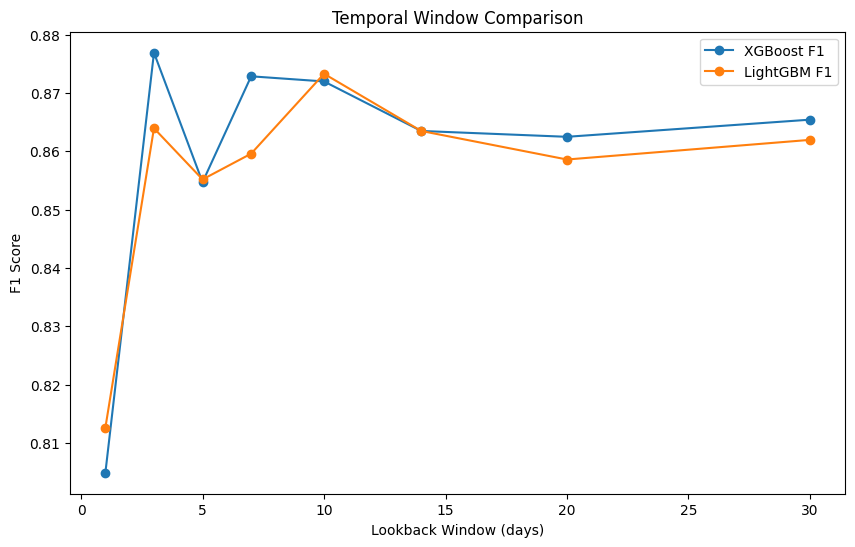

In [ ]:
# Visualization

plt.figure(figsize=(10,6))

plt.plot(
    lookback_results_df["Window"],
    lookback_results_df["XGB F1"],
    marker='o',
    label="XGBoost F1"
)

plt.plot(
    lookback_results_df["Window"],
    lookback_results_df["LGBM F1"],
    marker='o',
    label="LightGBM F1"
)

plt.xlabel("Lookback Window (days)")
plt.ylabel("F1 Score")

plt.title("Temporal Window Comparison")

plt.legend()

plt.show()

##6.2. Feature Set Ablation

In [ ]:
# Feature Set Ablation using XGBoost

feature_sets = {
    "Streamflow only": [
        c for c in features
        if c.startswith("flow_lag")
    ],

    "Streamflow + Precipitation": [
        c for c in features
        if c.startswith("flow_lag") or c.startswith("precip_lag")
    ],

    "Streamflow + Precipitation + Temperature": [
        c for c in features
        if c.startswith("flow_lag") or c.startswith("precip_lag") or c.startswith("temp_lag")
    ],

    "All Features + Aggregated Precipitation": features
}

In [ ]:
feature_ablation_results = []

for name, feature_set in feature_sets.items():

    X_train_fs = train[feature_set]
    X_test_fs = test[feature_set]

    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_train_fs, y_train)

    preds = model.predict(X_test_fs)

    cm = confusion_matrix(y_test, preds)

    tn, fp, fn, tp = cm.ravel()

    feature_ablation_results.append({
        "Feature Set": name,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds)
    })

feature_ablation_df = pd.DataFrame(feature_ablation_results)

feature_ablation_df

,Feature Set,TP,TN,FP,FN,Recall,F1 Score
0,Streamflow only,216,5118,34,82,0.724832,0.788321
1,Streamflow + Precipitation,223,5122,30,75,0.748322,0.809437
2,Streamflow + Precipitation + Temperature,227,5125,27,71,0.761745,0.822464
3,All Features + Aggregated Precipitation,254,5117,35,44,0.852349,0.865417


##6.3 Threshold Sensitivity Analysis

In [ ]:
# Threshold Sensitivity Analysis using XGBoost

threshold_results = []

thresholds = {
    "Q90": df["Streamflow"].quantile(0.90),
    "Q95": df["Streamflow"].quantile(0.95)
}

for threshold_name, threshold_value in thresholds.items():

    df_threshold = df.copy()

    df_threshold["target_threshold"] = (
        df_threshold["Streamflow"] > threshold_value
    ).astype(int)

    train_size = int(len(df_threshold) * 0.7)

    train_t = df_threshold.iloc[:train_size]
    test_t = df_threshold.iloc[train_size:]

    X_train_t = train_t[features]
    y_train_t = train_t["target_threshold"]

    X_test_t = test_t[features]
    y_test_t = test_t["target_threshold"]

    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_train_t, y_train_t)

    preds_t = model.predict(X_test_t)

    cm = confusion_matrix(y_test_t, preds_t)

    tn, fp, fn, tp = cm.ravel()

    threshold_results.append({
        "Threshold": threshold_name,
        "Threshold Value": threshold_value,
        "Positive Class Count": y_test_t.sum(),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Recall": recall_score(y_test_t, preds_t),
        "F1 Score": f1_score(y_test_t, preds_t)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Threshold Value,Positive Class Count,TP,TN,FP,FN,Recall,F1 Score
0,Q90,24.1,289,245,5124,37,44,0.847751,0.858144
1,Q95,42.8,117,93,5305,28,24,0.794872,0.781513


#7. Deep Learning (LSTM)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

In [ ]:
def create_sequences(data, feature_cols, target_col, window):

    X, y = [], []

    values = data[feature_cols].values
    targets = data[target_col].values

    for i in range(window, len(data)):

        X.append(values[i-window:i])

        y.append(targets[i])

    return np.array(X), np.array(y)

In [ ]:
sequence_features = ["Streamflow", "Precipitation", "Temperature"]
target_col = "target"

In [ ]:
lstm_results = []

windows = [1, 3, 14, 30, 45, 60, 90]

for window in windows:

    X_seq, y_seq = create_sequences(
        df,
        sequence_features,
        target_col,
        window
    )

    split_index = int(len(X_seq) * 0.7)

    X_train_seq = X_seq[:split_index]
    X_test_seq = X_seq[split_index:]

    y_train_seq = y_seq[:split_index]
    y_test_seq = y_seq[split_index:]

    model = Sequential([
        LSTM(32, input_shape=(window, len(sequence_features))),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train_seq,
        y_train_seq,
        epochs=10,
        batch_size=32,
        verbose=0
    )

    preds = model.predict(X_test_seq)

    preds_binary = (preds > 0.5).astype(int)

    if window == 30:
        lstm_probs = preds.ravel()
        lstm_y_test = y_test_seq

    recall = recall_score(y_test_seq, preds_binary)
    f1 = f1_score(y_test_seq, preds_binary)

    cm = confusion_matrix(y_test_seq, preds_binary)

    tn, fp, fn, tp = cm.ravel()

    lstm_results.append({
        "Window": window,

        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,

        "Recall": recall,
        "F1 Score": f1
    })

lstm_results_df = pd.DataFrame(lstm_results)

lstm_results_df

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


,Window,TP,TN,FP,FN,Recall,F1 Score
0,1,238,5105,47,60,0.798658,0.816467
1,3,235,5116,35,63,0.788591,0.827465
2,14,238,5119,29,60,0.798658,0.842478
3,30,236,5120,23,62,0.791946,0.847397
4,45,228,5115,23,70,0.765101,0.830601
5,60,236,5114,20,62,0.791946,0.851986
6,90,230,5102,23,68,0.771812,0.834846


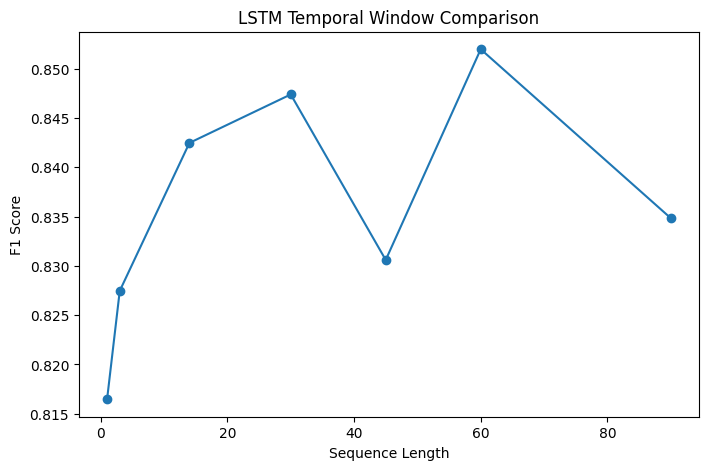

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    lstm_results_df["Window"],
    lstm_results_df["F1 Score"],
    marker='o'
)

plt.xlabel("Sequence Length")
plt.ylabel("F1 Score")

plt.title("LSTM Temporal Window Comparison")

plt.show()

#8. Results

##8.1. Confusion Matrix Comparison

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

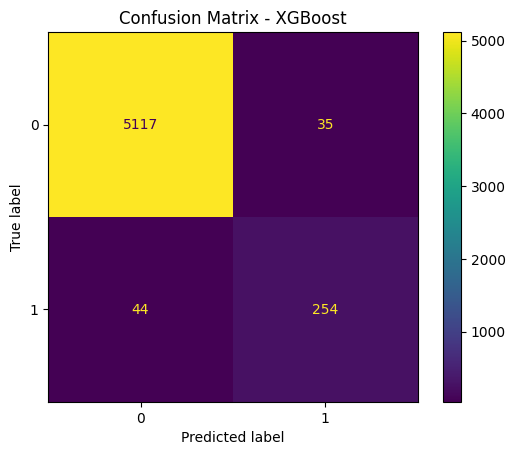

In [ ]:
cm_xgb = confusion_matrix(y_test, xgb_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb
)

disp.plot()

plt.title("Confusion Matrix - XGBoost")

plt.show()

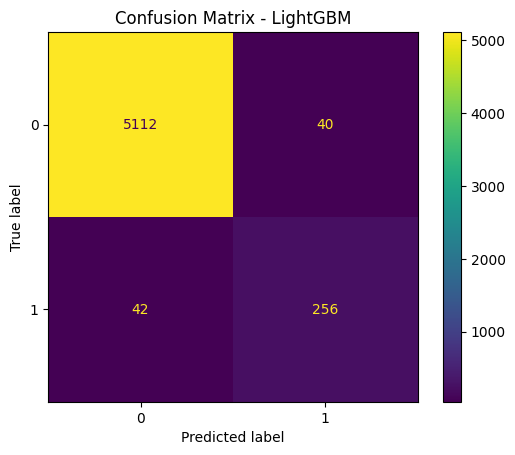

In [ ]:
cm_lgbm = confusion_matrix(y_test, lgbm_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm
)

disp.plot()

plt.title("Confusion Matrix - LightGBM")

plt.show()

In [ ]:
tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()

In [ ]:
lookback_results.append({

    "Window": w,

    "XGB TP": tp_xgb,
    "XGB TN": tn_xgb,
    "XGB FP": fp_xgb,
    "XGB FN": fn_xgb,

    "XGB Recall": xgb_recall,
    "XGB F1": xgb_f1,

    "LGBM TP": tp_lgbm,
    "LGBM TN": tn_lgbm,
    "LGBM FP": fp_lgbm,
    "LGBM FN": fn_lgbm,

    "LGBM Recall": lgbm_recall,
    "LGBM F1": lgbm_f1
})

In [ ]:
lookback_results_df

,Window,XGB TP,XGB TN,XGB FP,XGB FN,XGB Recall,XGB F1,LGBM TP,LGBM TN,LGBM FP,LGBM FN,LGBM Recall,LGBM F1
0,1,231,5107,45,67,0.775168,0.804878,232,5111,41,66,0.778523,0.812609
1,3,260,5117,35,38,0.872483,0.876897,254,5116,36,44,0.852349,0.863946
2,5,250,5115,37,48,0.838926,0.854701,248,5118,34,50,0.832215,0.855172
3,7,254,5122,30,44,0.852349,0.872852,251,5117,35,47,0.842282,0.859589
4,10,252,5124,28,46,0.845638,0.871972,255,5121,31,43,0.855705,0.873288
5,14,253,5117,35,45,0.848993,0.863481,253,5117,35,45,0.848993,0.863481
6,20,254,5115,37,44,0.852349,0.862479,255,5111,41,43,0.855705,0.858586
7,30,254,5117,35,44,0.852349,0.865417,256,5112,40,42,0.859060,0.861953


In [ ]:
lstm_results_df

,Window,TP,TN,FP,FN,Recall,F1 Score
0,1,222,5120,32,76,0.744966,0.804348
1,3,248,5112,39,50,0.832215,0.847863
2,14,240,5116,32,58,0.805369,0.842105
3,30,233,5122,21,65,0.781879,0.844203
4,45,225,5119,19,73,0.755034,0.830258
5,60,225,5117,17,73,0.755034,0.833333
6,90,228,5104,21,70,0.765101,0.833638


In [ ]:
baseline_results = []

models = {
    "Logistic Regression": lr_preds,
    "Random Forest": rf_preds,
    "XGBoost": xgb_preds,
    "LightGBM": lgbm_preds
}

for model_name, preds in models.items():
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()

    baseline_results.append({
        "Model": model_name,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds)
    })

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df

,Model,TP,TN,FP,FN,Recall,F1 Score
0,Logistic Regression,289,5016,136,9,0.969799,0.799447
1,Random Forest,235,5116,36,63,0.788591,0.826011
2,XGBoost,254,5117,35,44,0.852349,0.865417
3,LightGBM,256,5112,40,42,0.859060,0.861953


In [ ]:
# Best Configuration Selection

# -----------------------------
# Best XGBoost Configuration
# -----------------------------

best_xgb = lookback_results_df.loc[
    lookback_results_df["XGB F1"].idxmax()
]

print("Best XGBoost Configuration")
print(best_xgb)

print("\n")


# -----------------------------
# Best LightGBM Configuration
# -----------------------------

best_lgbm = lookback_results_df.loc[
    lookback_results_df["LGBM F1"].idxmax()
]

print("Best LightGBM Configuration")
print(best_lgbm)

print("\n")


# -----------------------------
# Best LSTM Configuration
# (Highest F1)
# -----------------------------

best_lstm_f1 = lstm_results_df.loc[
    lstm_results_df["F1 Score"].idxmax()
]

print("Best LSTM Configuration (Highest F1)")
print(best_lstm_f1)

print("\n")


# -----------------------------
# Best LSTM Configuration
# (Lowest False Negatives)
# -----------------------------

best_lstm_fn = lstm_results_df.loc[
    lstm_results_df["FN"].idxmin()
]

print("Best LSTM Configuration (Lowest FN)")
print(best_lstm_fn)

Best XGBoost Configuration
Window            3.000000
XGB TP          260.000000
XGB TN         5117.000000
XGB FP           35.000000
XGB FN           38.000000
XGB Recall        0.872483
XGB F1            0.876897
LGBM TP         254.000000
LGBM TN        5116.000000
LGBM FP          36.000000
LGBM FN          44.000000
LGBM Recall       0.852349
LGBM F1           0.863946
Name: 1, dtype: float64


Best LightGBM Configuration
Window           10.000000
XGB TP          252.000000
XGB TN         5124.000000
XGB FP           28.000000
XGB FN           46.000000
XGB Recall        0.845638
XGB F1            0.871972
LGBM TP         255.000000
LGBM TN        5121.000000
LGBM FP          31.000000
LGBM FN          43.000000
LGBM Recall       0.855705
LGBM F1           0.873288
Name: 4, dtype: float64


Best LSTM Configuration (Highest F1)
Window         3.000000
TP           248.000000
TN          5112.000000
FP            39.000000
FN            50.000000
Recall         0.832215
F1 Score  

##8.2. Best Model Comparison

In [ ]:
comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "LSTM"
    ],

    "Best F1": [
        baseline_results_df.loc[
            baseline_results_df["Model"] == "Logistic Regression",
            "F1 Score"
        ].values[0],

        baseline_results_df.loc[
            baseline_results_df["Model"] == "Random Forest",
            "F1 Score"
        ].values[0],

        best_xgb["XGB F1"],

        best_lgbm["LGBM F1"],

        best_lstm_f1["F1 Score"]
    ]
})

comparison_df

,Model,Best F1
0,Logistic Regression,0.799447
1,Random Forest,0.826011
2,XGBoost,0.876897
3,LightGBM,0.873288
4,LSTM,0.847863


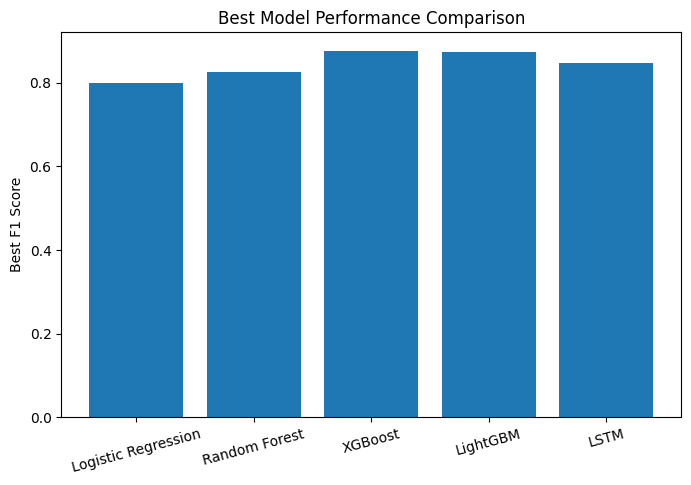

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Best F1"]
)

plt.ylabel("Best F1 Score")

plt.title("Best Model Performance Comparison")

plt.xticks(rotation=15)

plt.show()

##8.3. Precision-Recall Curve Comparison

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

precision_lstm, recall_lstm, _ = precision_recall_curve(
    lstm_y_test,
    lstm_probs
)

ap_lstm = average_precision_score(
    lstm_y_test,
    lstm_probs
)

print(ap_lstm)

0.9293509148090798


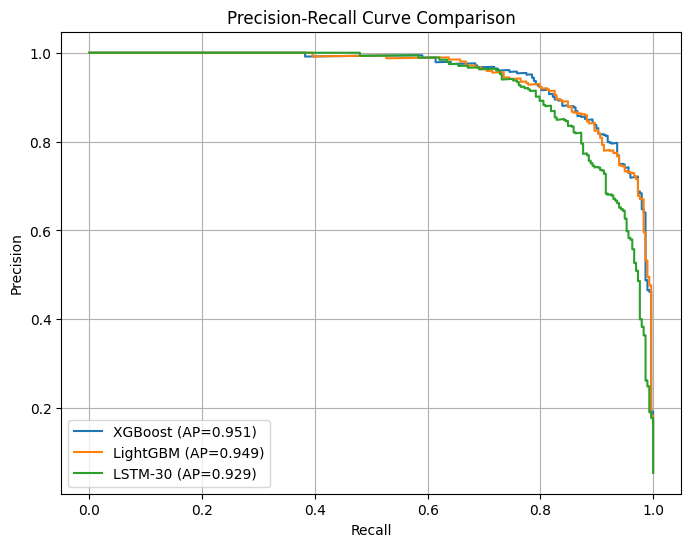

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(recall_xgb, precision_xgb, label=f"XGBoost (AP={ap_xgb:.3f})")
plt.plot(recall_lgbm, precision_lgbm, label=f"LightGBM (AP={ap_lgbm:.3f})")
plt.plot(recall_lstm, precision_lstm, label=f"LSTM-30 (AP={ap_lstm:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

##8.4. ROC Curve Comparison

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_lstm, tpr_lstm, _ = roc_curve(
    lstm_y_test,
    lstm_probs
)

auc_lstm = roc_auc_score(
    lstm_y_test,
    lstm_probs
)

print(auc_lstm)

0.9923418421076671


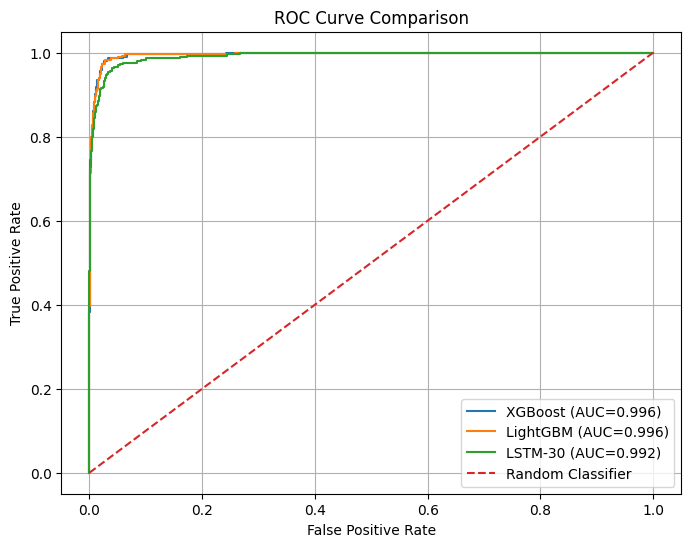

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC={auc_xgb:.3f})"
)

plt.plot(
    fpr_lgb,
    tpr_lgb,
    label=f"LightGBM (AUC={auc_lgb:.3f})"
)

plt.plot(
    fpr_lstm,
    tpr_lstm,
    label=f"LSTM-30 (AUC={auc_lstm:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()
plt.grid(True)

plt.show()

##8.5. SHAP Analysis

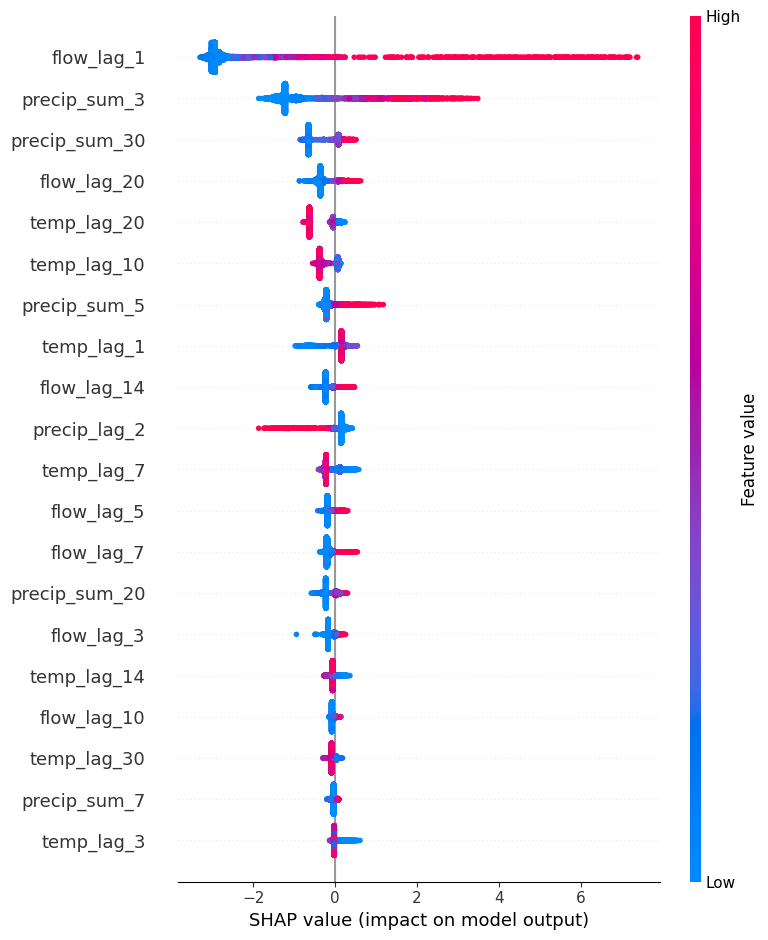

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

##8.6. Error Event Analysis - Missed Floods

In [ ]:
# Error Event Analysis - Missed Floods

error_df = X_test.copy()

error_df["Actual"] = y_test.values
error_df["Predicted"] = xgb_preds

missed_events = error_df[
    (error_df["Actual"] == 1) &
    (error_df["Predicted"] == 0)
]

missed_events.head()

,flow_lag_1,precip_lag_1,temp_lag_1,flow_lag_2,precip_lag_2,temp_lag_2,flow_lag_3,precip_lag_3,temp_lag_3,flow_lag_5,...,temp_lag_30,precip_sum_3,precip_sum_5,precip_sum_7,precip_sum_10,precip_sum_14,precip_sum_20,precip_sum_30,Actual,Predicted
12780,9.97,32.2,9.1,1.13,4.8,13.4,1.21,0.0,17.5,1.38,...,12.5,48.3,49.6,50.5,62.0,80.5,84.0,108.4,1,0
12792,2.79,3.6,12.2,1.96,0.0,10.7,2.26,0.0,14.3,3.13,...,7.3,40.6,40.6,40.6,43.1,90.6,97.6,131.1,1,0
12891,11.40,17.0,10.5,8.10,0.0,8.7,9.43,0.7,6.9,7.71,...,3.7,32.4,39.4,39.4,41.5,75.2,153.6,184.8,1,0
13126,11.90,32.4,10.7,1.21,4.9,15.6,2.71,0.0,13.7,5.90,...,13.1,39.2,40.3,65.1,85.7,86.0,91.5,145.3,1,0
13170,2.26,0.7,13.5,1.75,0.0,8.2,1.55,0.0,7.3,2.06,...,10.8,9.3,9.3,9.3,9.3,9.3,9.6,26.1,1,0


In [ ]:
missed_events.describe()

,flow_lag_1,precip_lag_1,temp_lag_1,flow_lag_2,precip_lag_2,temp_lag_2,flow_lag_3,precip_lag_3,temp_lag_3,flow_lag_5,...,temp_lag_30,precip_sum_3,precip_sum_5,precip_sum_7,precip_sum_10,precip_sum_14,precip_sum_20,precip_sum_30,Actual,Predicted
count,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,...,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.0,44.0
mean,17.874318,11.809091,10.065909,14.246818,5.852273,9.918182,15.705000,2.381818,9.270455,12.432045,...,9.484091,28.965909,36.086364,45.300000,54.997727,66.586364,84.422727,117.377273,1.0,0.0
std,9.491346,13.145267,3.636248,14.561175,8.322217,4.422000,19.658736,6.821657,5.076282,18.323756,...,4.369128,17.178474,16.809889,15.874654,20.705886,23.486429,30.456495,44.023450,0.0,0.0
min,2.260000,0.000000,2.000000,0.000000,0.000000,0.400000,0.000000,0.000000,-0.500000,0.000000,...,1.700000,0.800000,7.000000,9.300000,9.300000,9.300000,9.600000,26.100000,1.0,0.0
25%,9.727500,1.075000,7.750000,3.910000,0.000000,7.650000,2.597500,0.000000,5.575000,2.890000,...,6.525000,17.625000,26.550000,37.050000,41.275000,48.550000,63.000000,91.925000,1.0,0.0
50%,18.700000,8.750000,9.900000,7.775000,0.300000,9.200000,7.440000,0.000000,8.650000,5.760000,...,9.400000,27.900000,37.000000,45.600000,48.350000,64.350000,83.350000,107.300000,1.0,0.0
75%,26.325000,17.600000,12.250000,20.625000,10.500000,12.550000,21.575000,1.425000,12.350000,12.175000,...,11.925000,37.300000,45.725000,55.825000,62.975000,86.250000,98.325000,148.200000,1.0,0.0
max,36.300000,65.600000,19.100000,58.300000,27.300000,20.900000,78.400000,38.300000,21.600000,103.000000,...,24.800000,93.700000,93.700000,93.700000,115.600000,126.200000,153.600000,208.600000,1.0,0.0


In [ ]:
correct_events = error_df[
    (error_df["Actual"] == 1) &
    (error_df["Predicted"] == 1)
]

correct_events.describe()

,flow_lag_1,precip_lag_1,temp_lag_1,flow_lag_2,precip_lag_2,temp_lag_2,flow_lag_3,precip_lag_3,temp_lag_3,flow_lag_5,...,temp_lag_30,precip_sum_3,precip_sum_5,precip_sum_7,precip_sum_10,precip_sum_14,precip_sum_20,precip_sum_30,Actual,Predicted
count,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,...,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.0,254.0
mean,50.143976,9.087008,8.838189,46.076524,7.786614,9.251575,42.094965,6.667717,9.270472,37.250543,...,8.077165,23.320472,36.051575,46.706693,61.831102,79.922835,105.785433,146.300787,1.0,1.0
std,37.343320,11.221177,3.547710,39.594862,10.184378,3.398392,40.619971,9.079102,3.439855,39.609607,...,3.735953,18.666153,20.985811,23.525324,26.736572,29.711859,33.947758,41.894391,0.0,0.0
min,4.090000,0.000000,-0.500000,0.907000,0.000000,-0.500000,0.574000,0.000000,-0.300000,0.574000,...,0.100000,0.000000,0.000000,0.000000,0.000000,3.000000,28.500000,55.400000,1.0,1.0
25%,29.800000,0.000000,6.325000,22.800000,0.000000,7.200000,18.525000,0.000000,7.200000,11.925000,...,5.225000,7.600000,22.325000,30.775000,43.050000,55.775000,82.400000,113.575000,1.0,1.0
50%,40.600000,4.750000,9.200000,36.550000,2.900000,9.550000,31.150000,1.950000,9.200000,28.350000,...,8.200000,21.800000,34.600000,45.400000,58.900000,79.400000,101.700000,142.450000,1.0,1.0
75%,59.575000,15.000000,11.400000,58.875000,12.500000,11.500000,52.275000,10.575000,11.500000,47.600000,...,10.675000,33.350000,46.475000,60.300000,81.225000,104.000000,131.175000,177.950000,1.0,1.0
max,340.000000,56.400000,17.700000,340.000000,47.000000,17.700000,340.000000,47.000000,18.100000,340.000000,...,16.900000,96.100000,115.300000,115.300000,157.900000,157.900000,194.700000,278.200000,1.0,1.0


<Figure size 800x500 with 0 Axes>

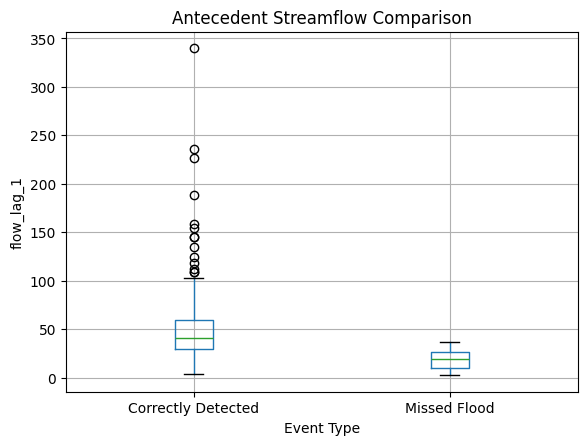

In [ ]:
comparison_plot_df = pd.DataFrame({

    "flow_lag_1": pd.concat([
        missed_events["flow_lag_1"],
        correct_events["flow_lag_1"]
    ]),

    "Event Type": (
        ["Missed Flood"] * len(missed_events)
        +
        ["Correctly Detected"] * len(correct_events)
    )
})

plt.figure(figsize=(8,5))

comparison_plot_df.boxplot(
    column="flow_lag_1",
    by="Event Type"
)

plt.title("Antecedent Streamflow Comparison")
plt.suptitle("")

plt.ylabel("flow_lag_1")

plt.show()

<Figure size 800x500 with 0 Axes>

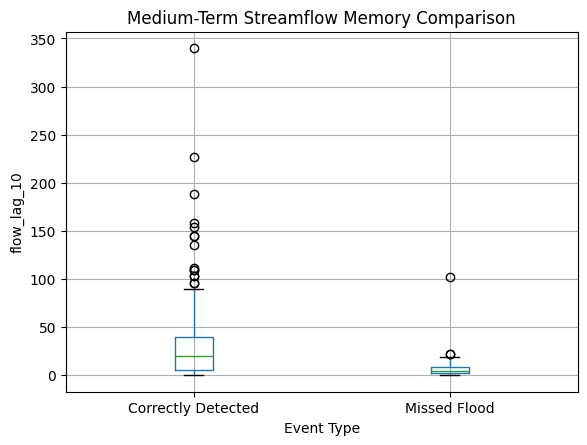

In [ ]:
comparison_plot_df = pd.DataFrame({

    "flow_lag_10": pd.concat([
        missed_events["flow_lag_10"],
        correct_events["flow_lag_10"]
    ]),

    "Event Type": (
        ["Missed Flood"] * len(missed_events)
        +
        ["Correctly Detected"] * len(correct_events)
    )
})

plt.figure(figsize=(8,5))

comparison_plot_df.boxplot(
    column="flow_lag_10",
    by="Event Type"
)

plt.title("Medium-Term Streamflow Memory Comparison")
plt.suptitle("")

plt.ylabel("flow_lag_10")

plt.xlabel("Event Type")

plt.show()